# PCA Reconstruction EDA

Dedicated notebook for pooled GTEx ground-truth PCA recovery analyses on cache-backed strict LORO rows.



In [ ]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.eval_utils.results_eda import *

In [22]:
import importlib
import src.eval_utils.results_eda as results_eda
importlib.reload(results_eda)
from src.eval_utils.results_eda import *



In [3]:
set_academic_style()

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    hvg_path='data/raw/ahba_100hvg.txt',
    cache_root='out/loro_subject_cache',
    gene_scope='allgenes',
    naive_cache_dirname='naive',
    dlam_cache_dirname='dlam',
    plam_cache_dirname='plam',
)
CFG
print('analysis scope:', CFG.gene_scope)



analysis scope: allgenes


## 1) Dataset Context

This notebook treats each subject-parcel row as a sample and each gene as a feature.
So the PCA fit matrix has shape:

$$
X_{\mathrm{true},h} \in \mathbb{R}^{n_{\mathrm{samples}} \times n_{\mathrm{genes}}}
$$

Here $n_{\mathrm{samples}}$ is the total number of strict held-out subject-parcel rows pooled across eligible subjects, not the number of subjects and not the full atlas size including AHBA.



In [ ]:
PREPOST = prepare_pre_post_harmonization(CFG)
print('eligible subjects:', len(PREPOST['subjects']))
print('genes:', len(PREPOST['genes']))
print('parcels:', PREPOST['raw_cube'].shape[1])


eligible subjects: 318
genes: 13618
parcels: 150


## 2) Pooled Sample Matrices

We first pull two aligned pooled data frames from cache:
- `truth_df_*`: strict held-out truth rows
- `pred_df_*`: aligned model prediction rows on the same `(subject, parcel_idx)` keys

In [5]:
MODELS = ['naive', 'dlam', 'plam']
N_JOBS = 16
EVAL_GENE_PATH = None  # set to 'ahba_100hvg', 'gtex_100hvg', 'gtex_25deg', etc.

truth_df_naive, pred_df_naive = collect_pooled_sample_prediction_dfs_from_cache_gene_subset(
    CFG,
    model='naive',
    eval_gene_path=EVAL_GENE_PATH,
    n_jobs=N_JOBS,
)
truth_df_dlam, pred_df_dlam = collect_pooled_sample_prediction_dfs_from_cache_gene_subset(
    CFG,
    model='dlam',
    eval_gene_path=EVAL_GENE_PATH,
    n_jobs=N_JOBS,
)
truth_df_plam, pred_df_plam = collect_pooled_sample_prediction_dfs_from_cache_gene_subset(
    CFG,
    model='plam',
    eval_gene_path=EVAL_GENE_PATH,
    n_jobs=N_JOBS,
)

display(truth_df_naive.head())
display(pred_df_naive.head())
print('naive shapes:', truth_df_naive.shape, pred_df_naive.shape)
print('sample keys aligned:', (truth_df_naive['sample_key'] == pred_df_naive['sample_key']).all())



,subject,parcel_idx,sample_key,sample_idx_subject,model,eval_gene_mode,eval_gene_path,mixed_space_mode,DPM1,SCYL3,...,MRM1,HIST1H4A,GOLGA6L10,HIST1H2AM,HIST1H4B,HIST1H3H,MRPL45,PCDH20,PAGR1,TMEM265
0,GTEX-1117F,5,GTEX-1117F|5,0,naive,all,None,None,5.237353,3.014178,...,2.943969,1.561887,3.505472,4.470888,4.863447,2.127437,5.699000,1.250517,6.218362,3.250597
1,GTEX-1117F,10,GTEX-1117F|10,1,naive,all,None,None,5.246482,3.045238,...,3.217235,1.506255,3.542502,4.555119,4.862676,1.319629,5.581843,3.912728,6.362165,3.091069
2,GTEX-1117F,18,GTEX-1117F|18,2,naive,all,None,None,5.184985,3.045365,...,3.291385,1.506969,3.492359,4.798620,4.864834,1.686910,5.499541,4.284439,6.362572,3.103423
3,GTEX-1117F,19,GTEX-1117F|19,3,naive,all,None,None,5.299481,3.069595,...,3.244307,1.506277,3.575236,4.810700,4.862178,1.487257,5.653855,3.580846,6.368560,3.076855
4,GTEX-1117F,29,GTEX-1117F|29,4,naive,all,None,None,5.407557,3.060759,...,2.908304,1.506248,3.545862,4.516249,4.863857,2.449167,5.933543,2.875592,6.387455,3.082352


,subject,parcel_idx,sample_key,sample_idx_subject,model,eval_gene_mode,eval_gene_path,mixed_space_mode,DPM1,SCYL3,...,MRM1,HIST1H4A,GOLGA6L10,HIST1H2AM,HIST1H4B,HIST1H3H,MRPL45,PCDH20,PAGR1,TMEM265
0,GTEX-1117F,5,GTEX-1117F|5,0,naive,all,None,None,5.160922,2.381735,...,3.165953,1.541428,3.673922,5.244865,5.976554,2.313064,5.854665,0.984247,6.954978,3.086737
1,GTEX-1117F,10,GTEX-1117F|10,1,naive,all,None,None,5.847799,3.151138,...,3.765726,0.781725,4.536182,5.834588,6.065064,2.181073,6.716814,3.883568,8.021265,3.469866
2,GTEX-1117F,18,GTEX-1117F|18,2,naive,all,None,None,5.777831,3.140528,...,2.402404,2.859330,4.503953,6.386307,7.091222,3.478383,6.251956,4.185190,7.502801,3.259064
3,GTEX-1117F,19,GTEX-1117F|19,3,naive,all,None,None,5.911385,3.194874,...,3.351465,1.028587,4.582115,6.167117,6.120930,2.024480,6.840936,3.495154,7.928071,3.370401
4,GTEX-1117F,29,GTEX-1117F|29,4,naive,all,None,None,5.314977,3.032518,...,2.632245,1.136881,4.177752,6.433882,6.511618,2.640820,6.304029,3.872395,7.393399,2.938594


naive shapes: (2820, 13626) (2820, 13626)
sample keys aligned: True


In [ ]:
meta_cols = ['subject', 'parcel_idx', 'sample_key', 'sample_idx_subject', 'model', 'eval_gene_mode', 'eval_gene_path', 'mixed_space_mode']
gene_cols = [c for c in truth_df_naive.columns if c not in meta_cols]

X_true_h = truth_df_naive[gene_cols].to_numpy(dtype=np.float64)
X_pred_naive_h = pred_df_naive[gene_cols].to_numpy(dtype=np.float64)
X_pred_dlam_h = pred_df_dlam[gene_cols].to_numpy(dtype=np.float64)
X_pred_plam_h = pred_df_plam[gene_cols].to_numpy(dtype=np.float64)

print('X_true_h:', X_true_h.shape)
print('X_pred_naive_h:', X_pred_naive_h.shape)
print('X_pred_dlam_h:', X_pred_dlam_h.shape)
print('X_pred_plam_h:', X_pred_plam_h.shape)

# inspect why we only have 2820 samples instead of the full 3030

X_true_h: (2820, 13618)
X_pred_naive_h: (2820, 13618)
X_pred_dlam_h: (2820, 13618)
X_pred_plam_h: (2820, 13618)


## 3) Standard Pooled PCA

This is the default pooled PCA analysis.

What happens mathematically:
- fit PCA on `X_true_h`
- sklearn PCA centers each gene globally across all pooled samples
- project each model prediction matrix into that same truth PCA basis
- compare true vs predicted PC scores component-wise across the pooled sample axis

Why the naive model can look nontrivial here:
- pooled PCA still contains parcel fixed effects
- naive fill reproduces parcel template structure reasonably well
- so it can score well on parcel-driven PCs even if it misses subject-specific variation



In [7]:
pc_df, pc_summary = compute_pooled_pca_recovery_from_cache_gene_subset(
    CFG,
    num_pcs=300,
    models=MODELS,
    eval_gene_path=EVAL_GENE_PATH,
    demean_mode='none',
    n_jobs=N_JOBS,
)

spectra_df, spectra_summary = compute_pooled_pca_variance_spectra_from_cache_gene_subset(
    CFG,
    num_pcs=300,
    models=MODELS,
    eval_gene_path=EVAL_GENE_PATH,
    demean_mode='none',
    n_jobs=N_JOBS,
)

display(pc_summary)
display(spectra_summary)



,model,mean_score_pearson,var_weighted_score_pearson,pc1_score_pearson,pc95_cutoff,n_samples,n_genes,num_pcs,eval_gene_mode,eval_gene_path,demean_mode,mixed_space_mode
0,naive,0.024377,0.375030,0.150669,213,2820,13618,300,all,None,none,None
1,dlam,0.367923,0.312831,0.168591,213,2820,13618,300,all,None,none,None
2,plam,0.235848,0.354461,0.155212,213,2820,13618,300,all,None,none,None


,source,pc1_explained_variance_ratio,pc95_cutoff,n_samples,n_genes,num_pcs,eval_gene_mode,eval_gene_path,demean_mode,mixed_space_mode
0,truth,0.283535,213,2820,13618,300,all,None,none,None
1,naive,0.424601,7,2820,13618,300,all,None,none,None
2,dlam,0.831589,8,2820,13618,300,all,None,none,None
3,plam,0.583388,9,2820,13618,300,all,None,none,None


In [17]:
spectra_df

,source,component,explained_variance_ratio,cumulative_variance,pc95_cutoff,n_samples,n_genes,num_pcs,eval_gene_mode,eval_gene_path,demean_mode,mixed_space_mode
0,truth,1,0.283535,0.283535,213,2820,13618,300,all,None,none,None
1,truth,2,0.158005,0.441540,213,2820,13618,300,all,None,none,None
2,truth,3,0.098467,0.540007,213,2820,13618,300,all,None,none,None
3,truth,4,0.069582,0.609589,213,2820,13618,300,all,None,none,None
4,truth,5,0.052536,0.662125,213,2820,13618,300,all,None,none,None
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,plam,296,0.000013,0.998500,9,2820,13618,300,all,None,none,None
1196,plam,297,0.000012,0.998513,9,2820,13618,300,all,None,none,None
1197,plam,298,0.000012,0.998525,9,2820,13618,300,all,None,none,None
1198,plam,299,0.000012,0.998537,9,2820,13618,300,all,None,none,None


### Standard PCA Variance Spectrum By Source

Each source gets its own PCA variance-spectrum plot.

Why this comes first:
- it shows the intrinsic variance geometry of the truth matrix and of each model matrix separately
- the 95% threshold is source-specific here, so each panel answers: how many PCs does *this* source need to explain most of its own variance?



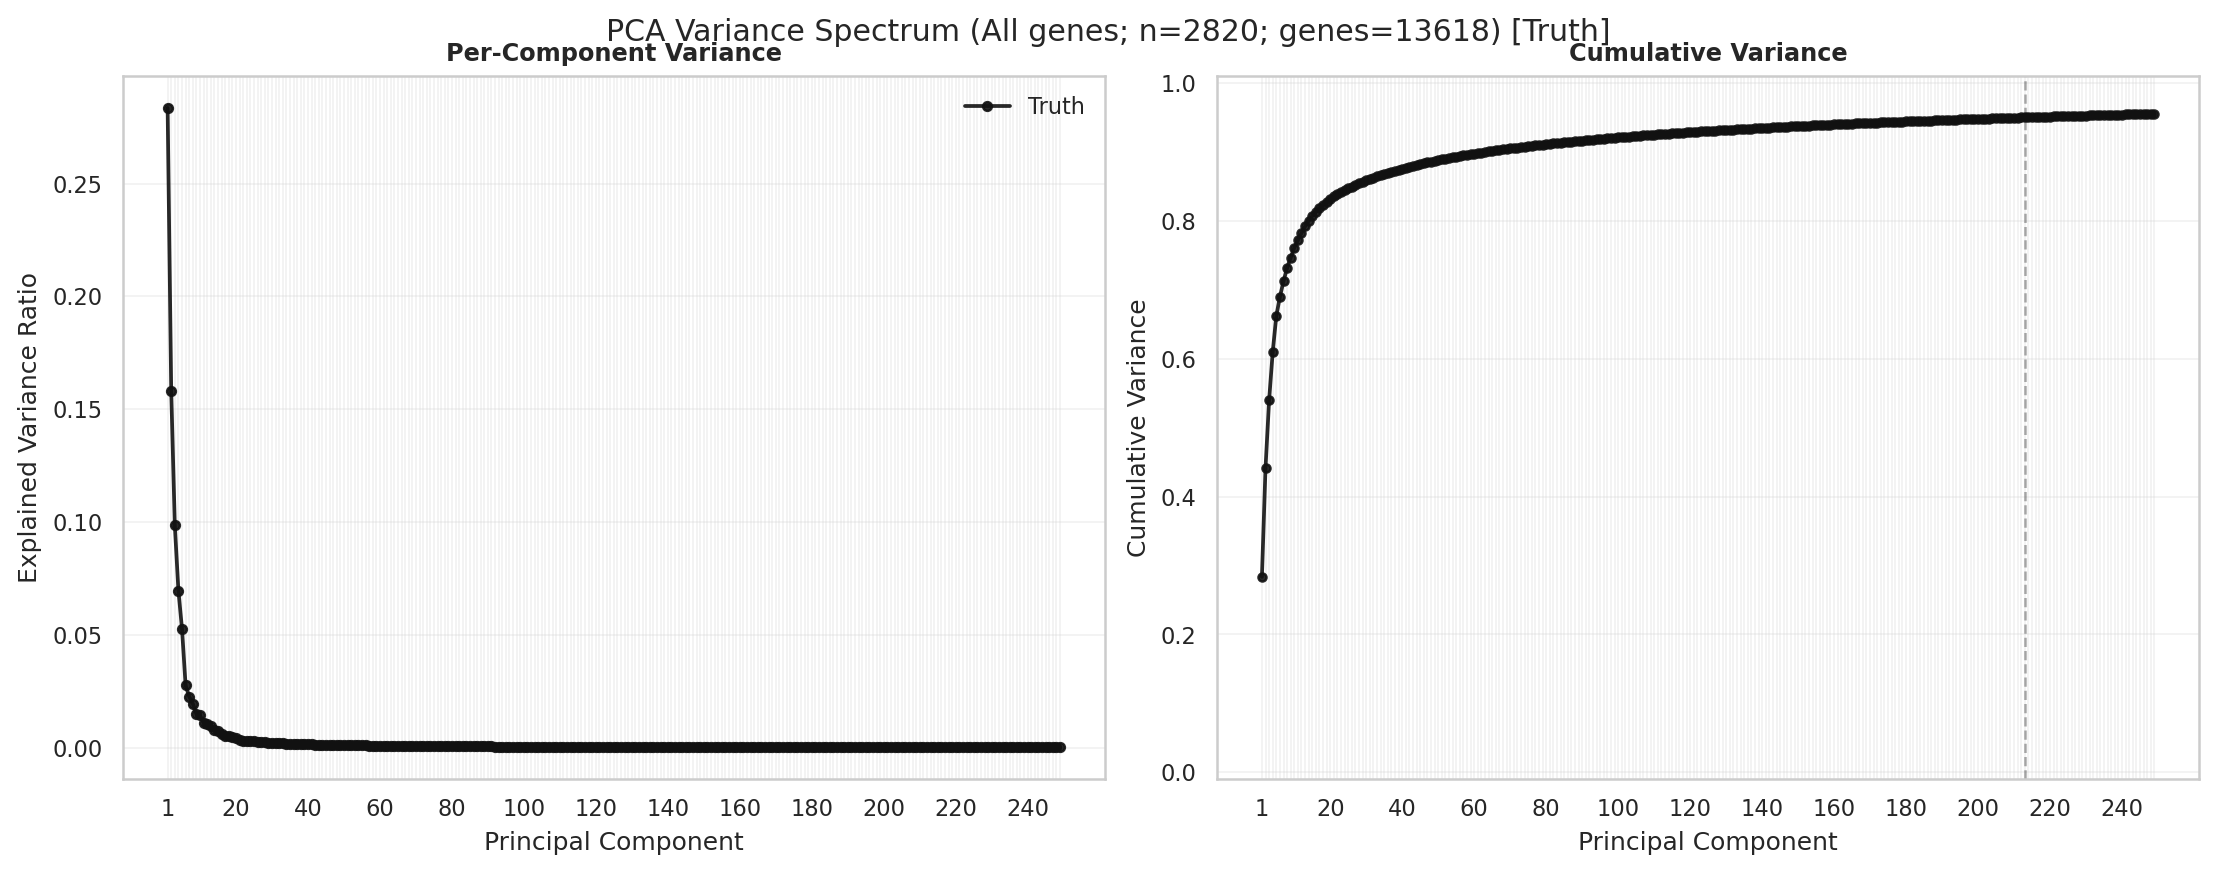

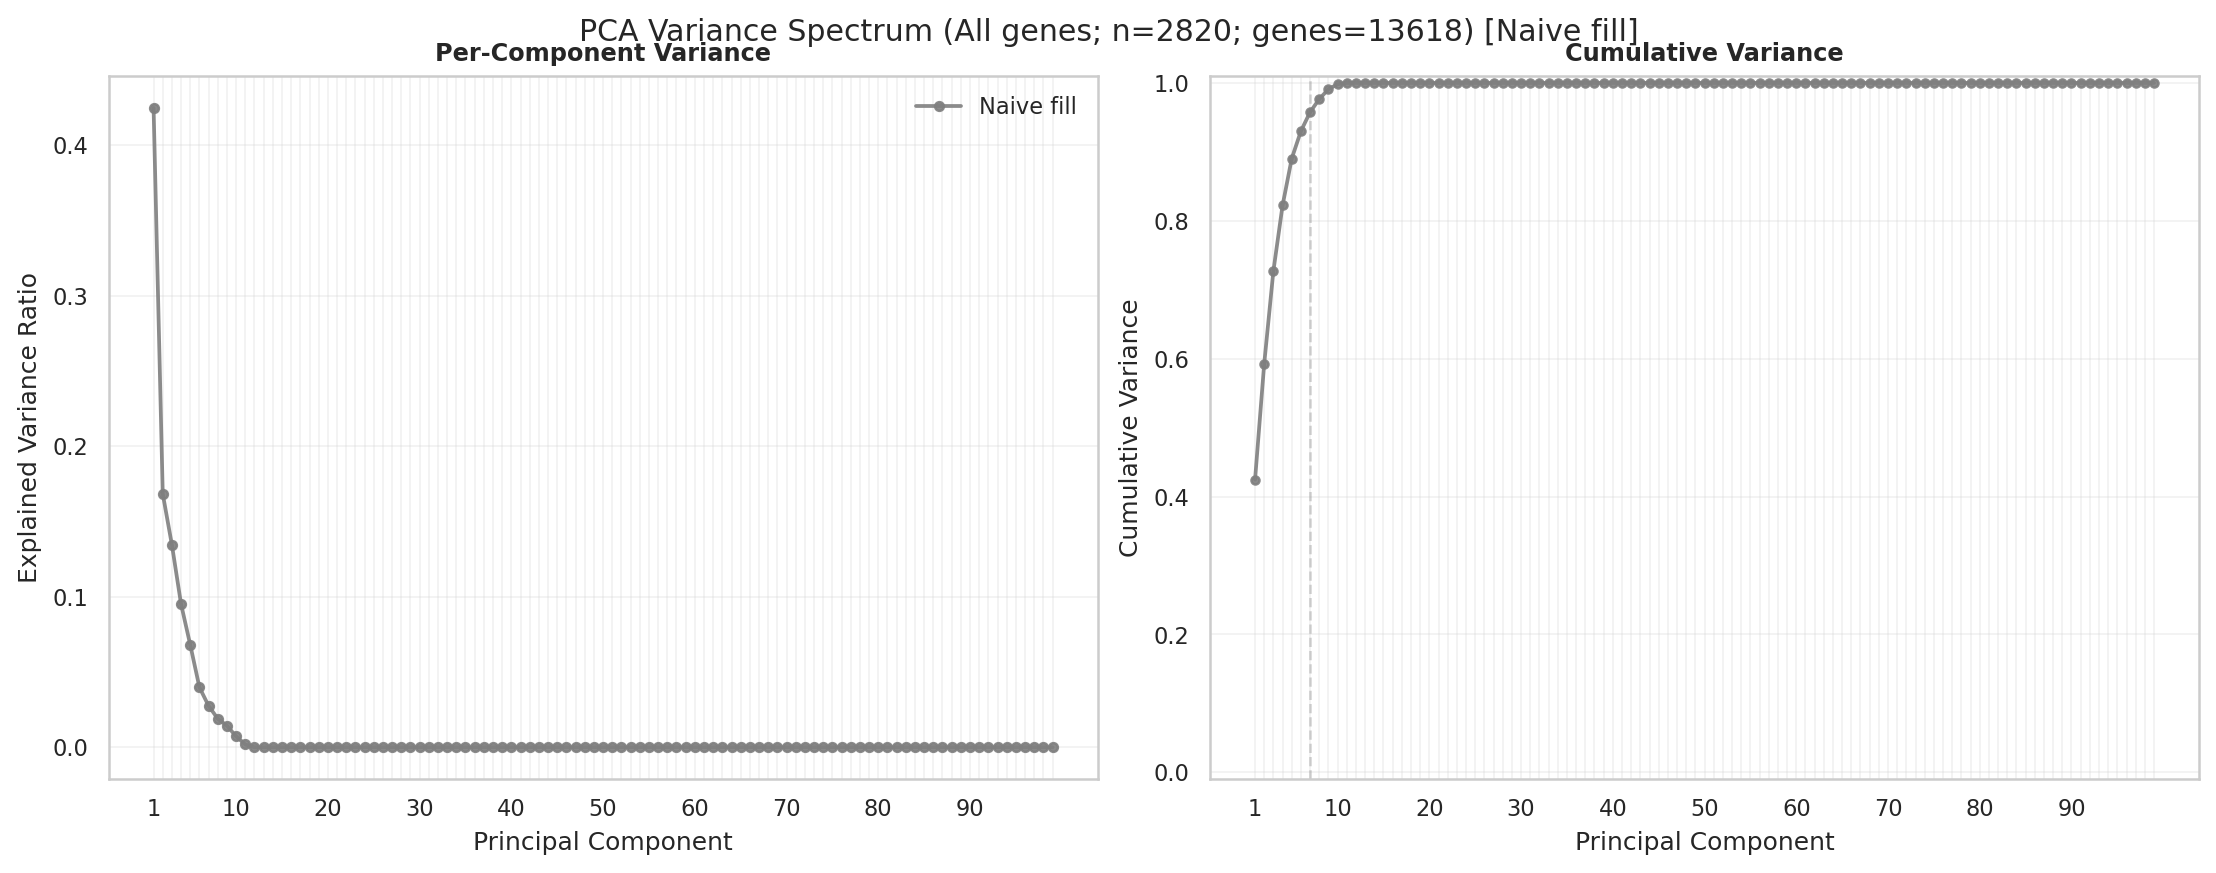

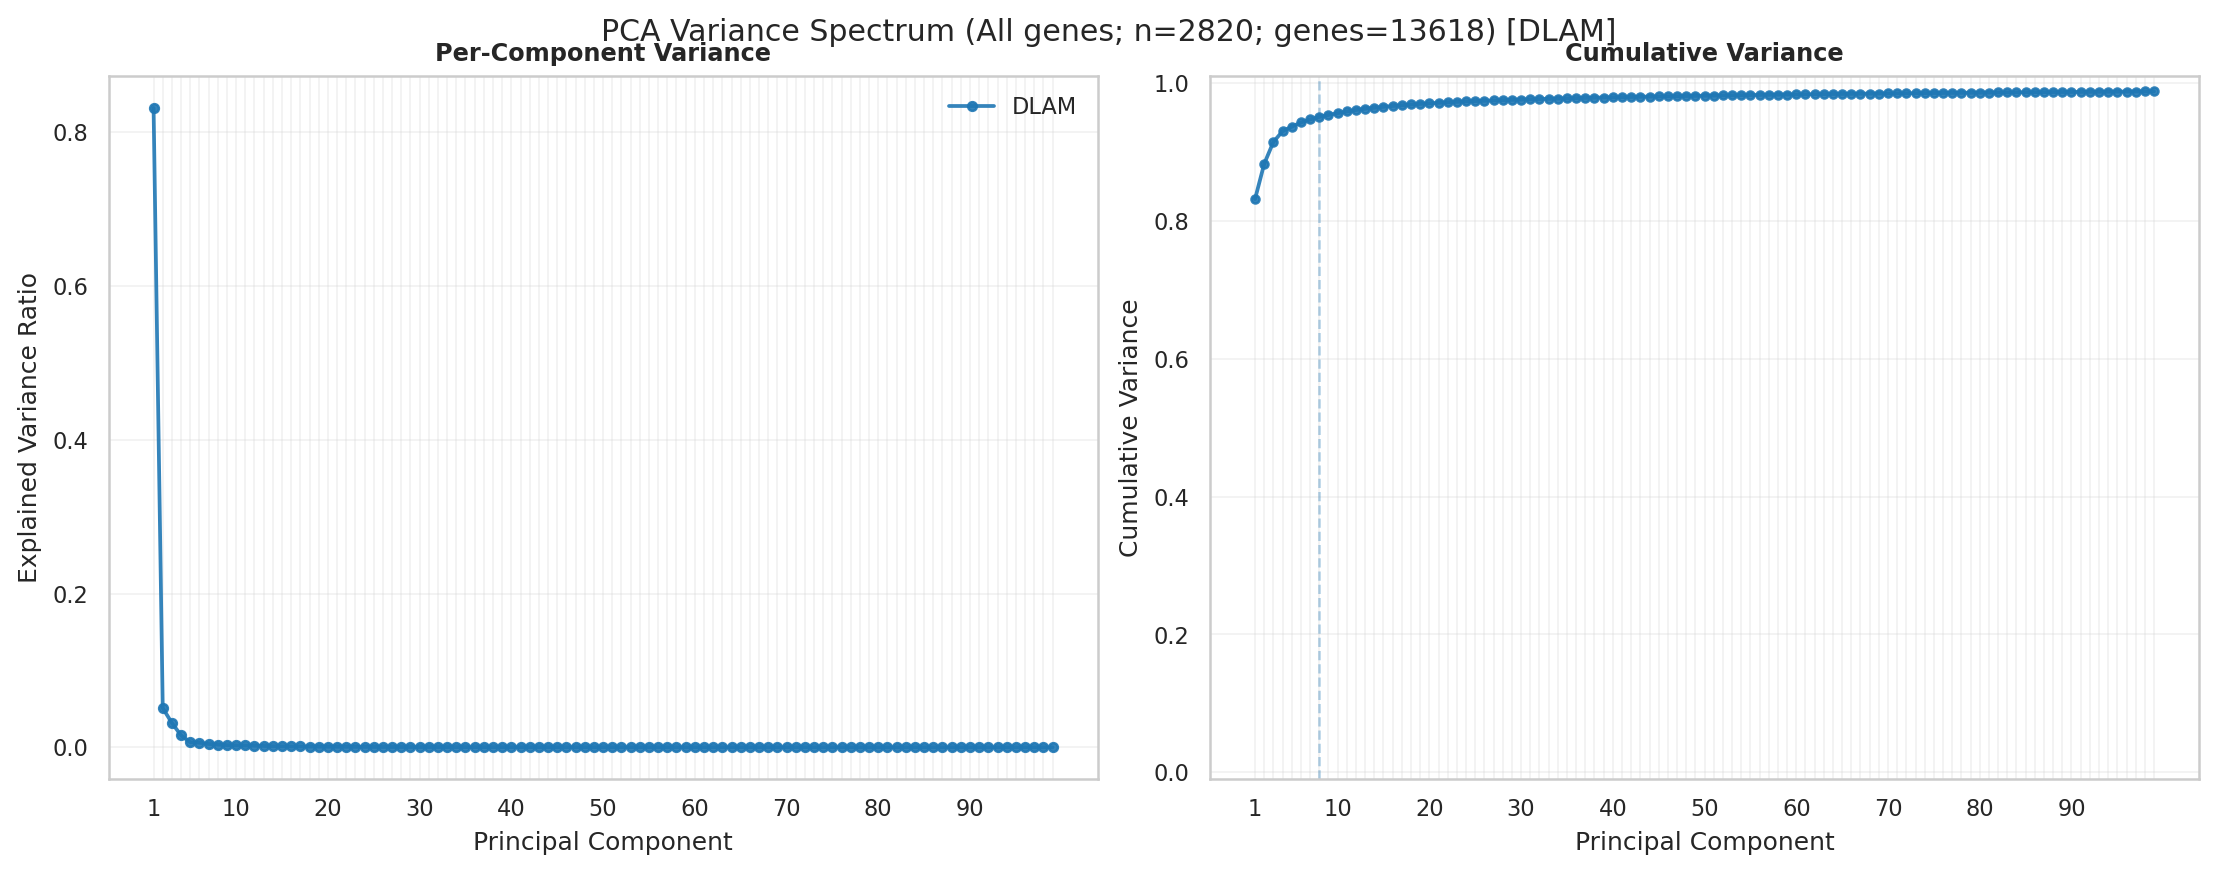

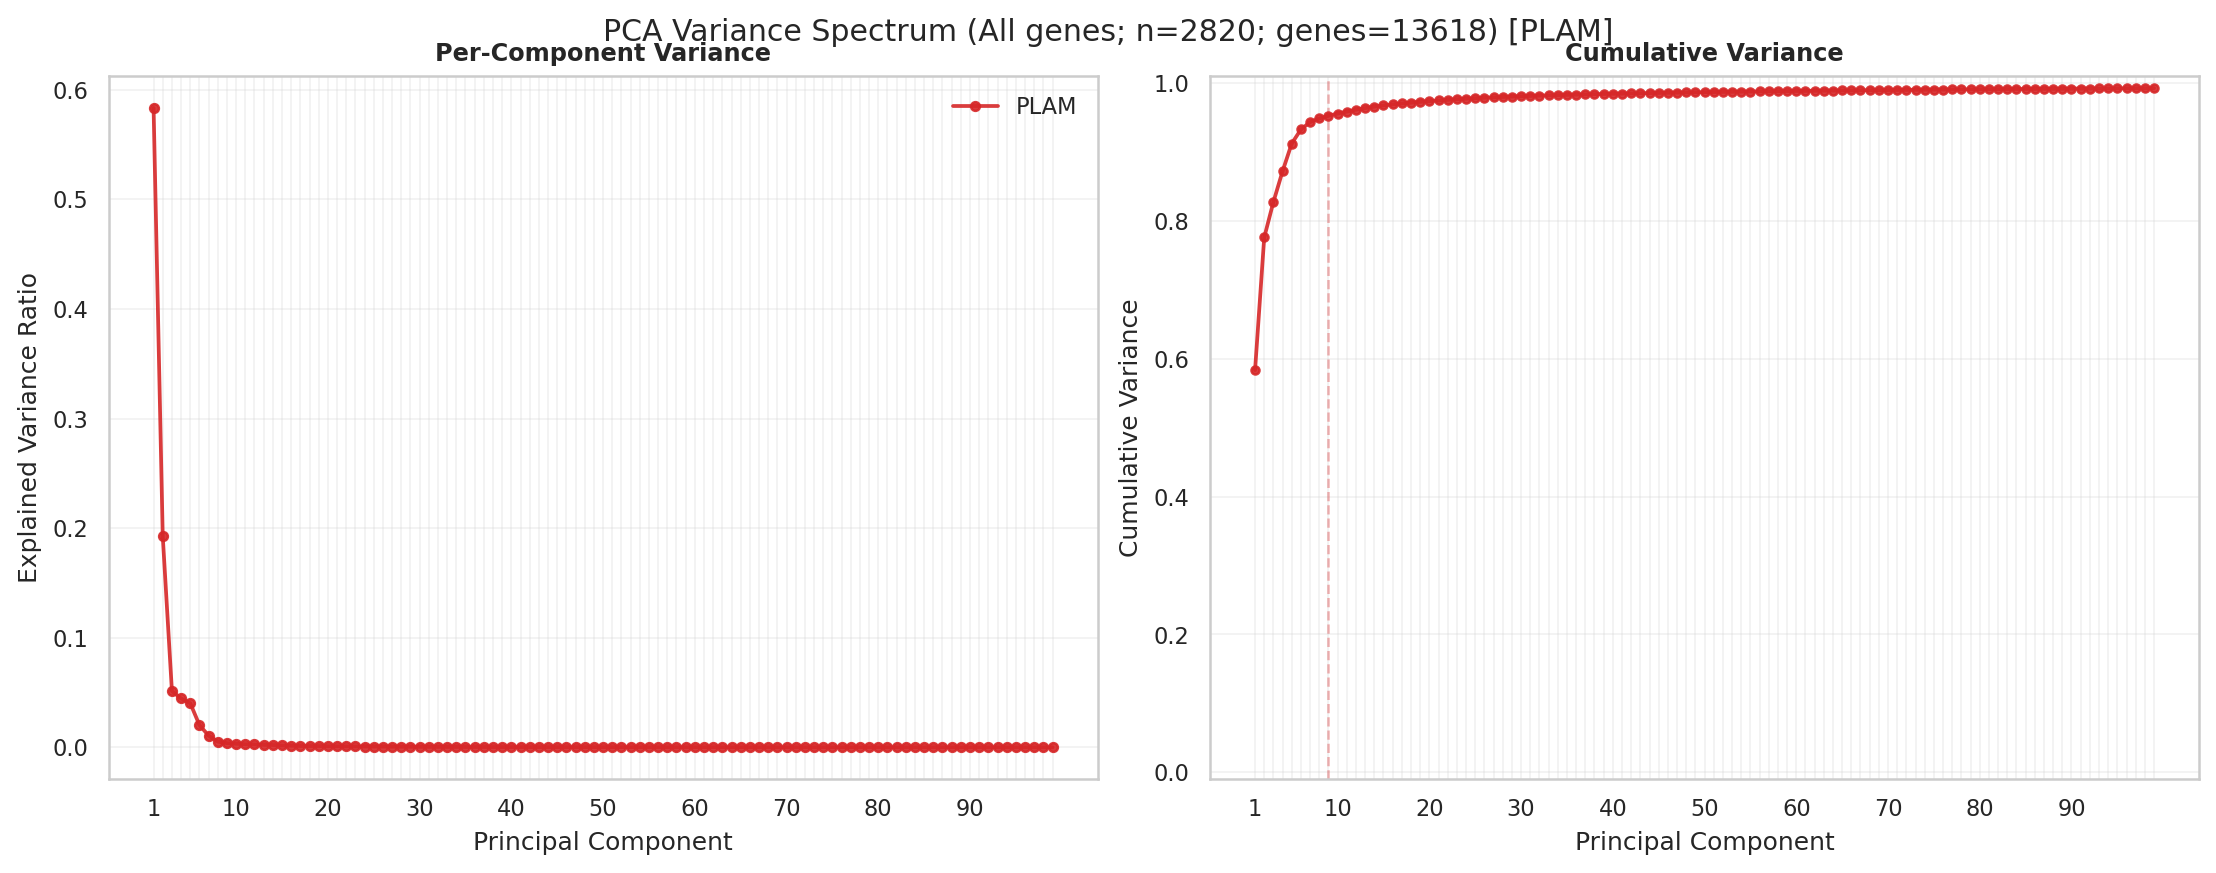

In [19]:
# Plot for 'truth' with 250 PCs and x_label_stride=20
fig, axes, _ = plot_pooled_pca_variance_spectra(
    spectra_df[(spectra_df['source'] == 'truth') & (spectra_df['component'] < 250)],
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
    show_decay_fit=False,
    x_label_stride=20,
    source='truth',
)

# Plot for 'naive' with 100 PCs and x_label_stride=10
fig, axes, _ = plot_pooled_pca_variance_spectra(
    spectra_df[(spectra_df['source'] == 'naive') & (spectra_df['component'] < 100)],
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
    show_decay_fit=False,
    x_label_stride=10,
    source='naive',
)

# Plot for 'dlam' with 100 PCs and x_label_stride=10
fig, axes, _ = plot_pooled_pca_variance_spectra(
    spectra_df[(spectra_df['source'] == 'dlam') & (spectra_df['component'] < 100)],
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
    show_decay_fit=False,
    x_label_stride=10,
    source='dlam',
)

# Plot for 'plam' with 100 PCs and x_label_stride=10
fig, axes, _ = plot_pooled_pca_variance_spectra(
    spectra_df[(spectra_df['source'] == 'plam') & (spectra_df['component'] < 100)],
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
    show_decay_fit=False,
    x_label_stride=10,
    source='plam',
)


### Standard PCA Recovery: Raw Line Plot

This plot asks a different question than the variance spectrum.

Here the PCA basis is always defined by truth, and we ask for each component `j` how well the predicted scores align with the true scores across pooled samples:
- compare `C_true[:, j]` to `C_pred[:, j]`

So this is a component-wise recovery plot, not a model-specific variance-spectrum plot.



/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/results_eda.py:2162: RuntimeWarning: overflow encountered in exp
  


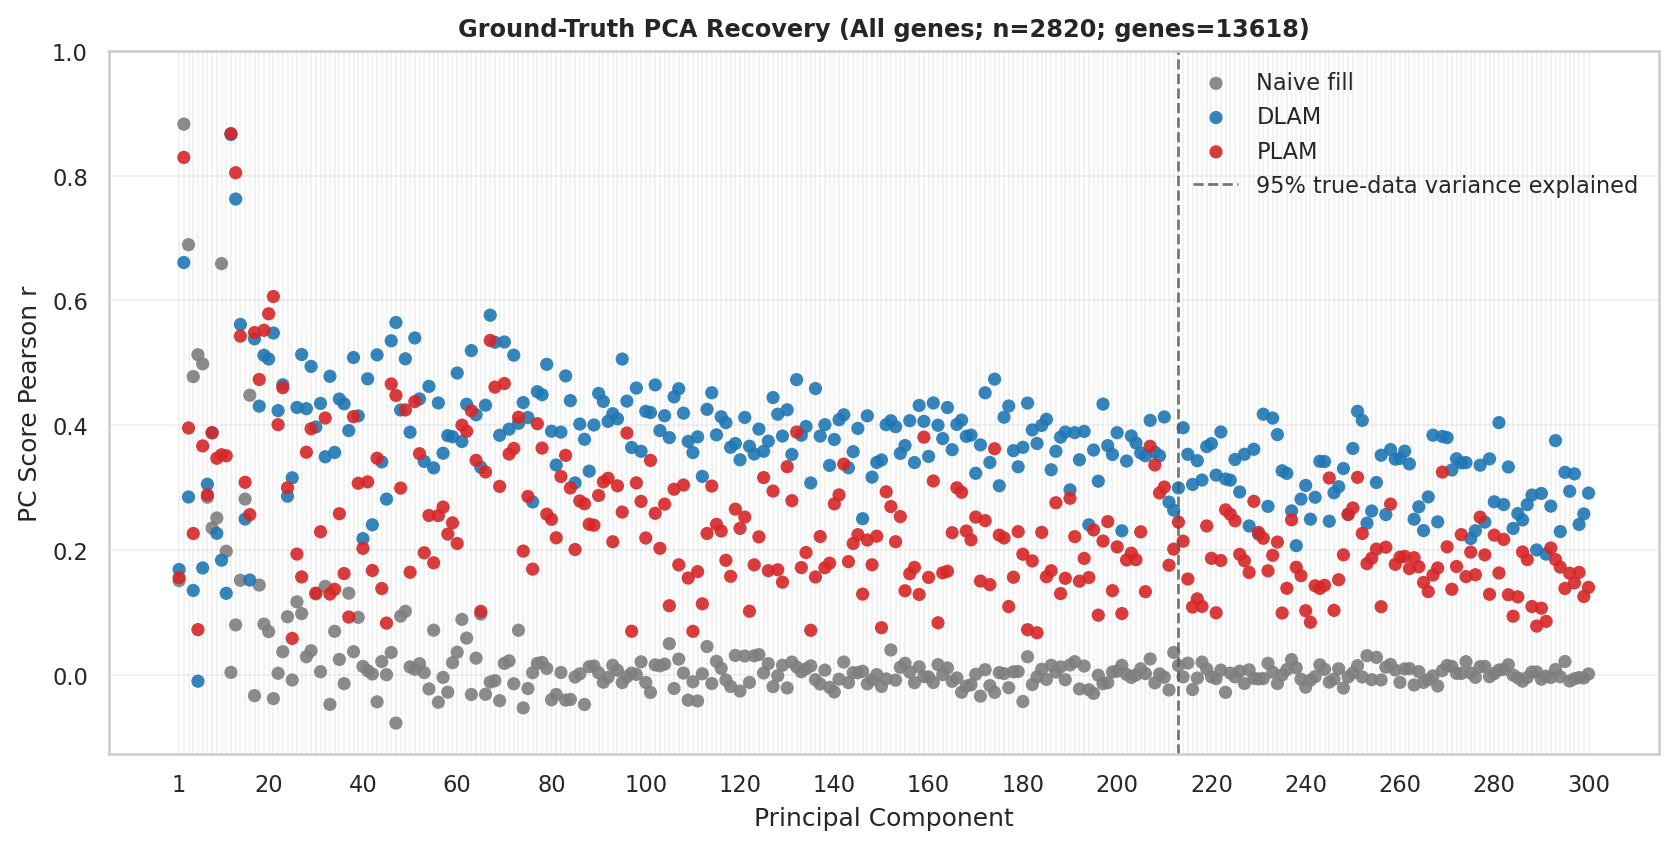

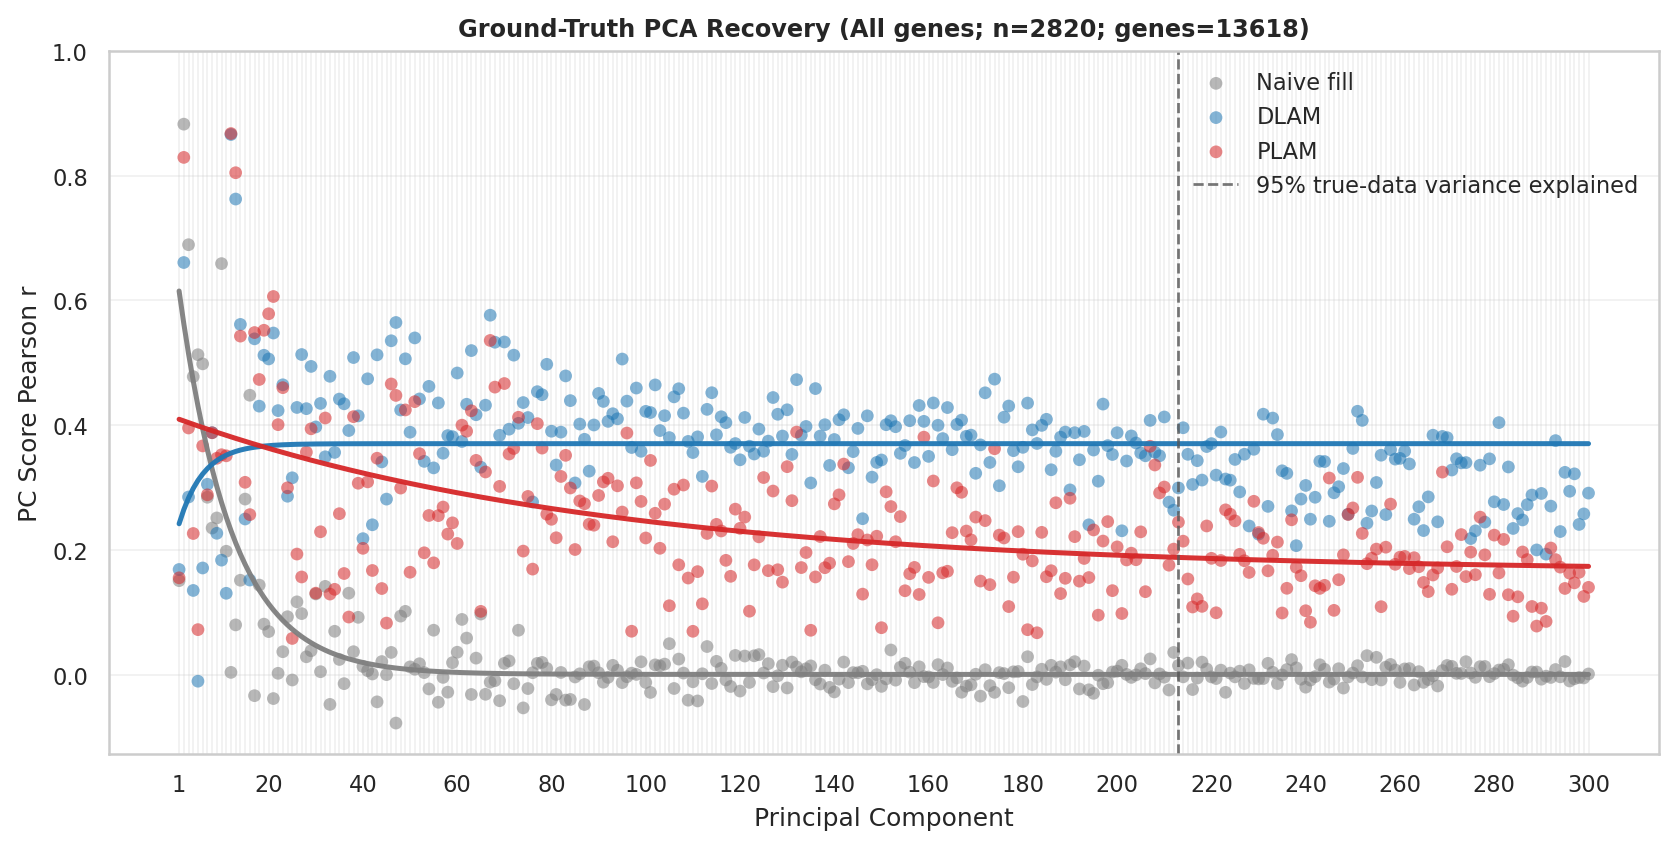

In [ ]:
fig, ax, pc_plot_df = plot_pooled_pca_recovery(
    pc_df,
    metric='score_pearson',
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
    show_lines=False,
    show_decay_fit=False,
    x_label_stride=20,
)

fig, ax, pc_plot_df_fit = plot_pooled_pca_recovery(
    pc_df,
    metric='score_pearson',
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
    show_decay_fit=True,
    x_label_stride=20,
)
# BUG CHECK FLAT 1S

## 4) Within-Parcel Demeaned Pooled PCA

This version explicitly removes parcel mean structure before PCA.

Mathematically, if sample $i$ belongs to parcel $p(i)$ and gene $g$ has value $x_{ig}$, define the truth parcel mean by

$$
\bar{x}_{pg} = \frac{1}{n_p} \sum_{i : p(i)=p} x_{ig}
$$

where $n_p$ is the number of pooled samples assigned to parcel $p$.

Then subtract that parcel mean within parcel:

$$
r_{ig} = x_{ig} - \bar{x}_{p(i)g}
$$

PCA is then fit on the residual matrix $R = [r_{ig}]$, after the usual global gene-wise centering performed by PCA itself.

Why this is useful:
- **the first step projects out the parcel fixed effect** (by parcel)
- the second step recenters the residual feature space for PCA (by gene)
- what remains is much more focused on subject-specific variation within parcel

Expected consequence for naive:
- naive fill mostly captures parcel-wise template effects
- once parcel means are removed, its residual structure should collapse toward zero

Expected consequence for DLAM/PLAM:
- if they reconstruct subject-varying residuals within parcel, they should remain above zero in this residualized PCA space


In [11]:
pc_df_dm, pc_summary_dm = compute_pooled_pca_recovery_from_cache_gene_subset(
    CFG,
    num_pcs=300,
    models=MODELS,
    eval_gene_path=EVAL_GENE_PATH,
    demean_mode='within_parcel',
    n_jobs=N_JOBS,
)

spectra_df_dm, spectra_summary_dm = compute_pooled_pca_variance_spectra_from_cache_gene_subset(
    CFG,
    num_pcs=300,
    models=MODELS,
    eval_gene_path=EVAL_GENE_PATH,
    demean_mode='within_parcel',
    n_jobs=N_JOBS,
)

display(pc_summary_dm)
display(spectra_summary_dm)



,model,mean_score_pearson,var_weighted_score_pearson,pc1_score_pearson,pc95_cutoff,n_samples,n_genes,num_pcs,eval_gene_mode,eval_gene_path,demean_mode,mixed_space_mode
0,naive,-0.000089,-0.000078,-0.000011,300,2820,13618,300,all,None,within_parcel,None
1,dlam,0.317912,0.229477,0.152228,300,2820,13618,300,all,None,within_parcel,None
2,plam,0.197470,0.226160,0.163759,300,2820,13618,300,all,None,within_parcel,None


,source,pc1_explained_variance_ratio,pc95_cutoff,n_samples,n_genes,num_pcs,eval_gene_mode,eval_gene_path,demean_mode,mixed_space_mode
0,truth,0.383996,300,2820,13618,300,all,None,within_parcel,None
1,naive,0.349920,8,2820,13618,300,all,None,within_parcel,None
2,dlam,0.819622,10,2820,13618,300,all,None,within_parcel,None
3,plam,0.592247,13,2820,13618,300,all,None,within_parcel,None


### Within-Parcel Demeaned Variance Spectrum By Source

These source-specific spectra now reflect residual variance after parcel means are removed.

Why the expected result changes:
- naive can look structured in the standard spectrum because it captures parcel fixed effects
- after parcel demeaning, the spectrum focuses on subject-specific residual variation within parcel
- this is where learned models should differ most clearly from naive if they reconstruct subject-level variance



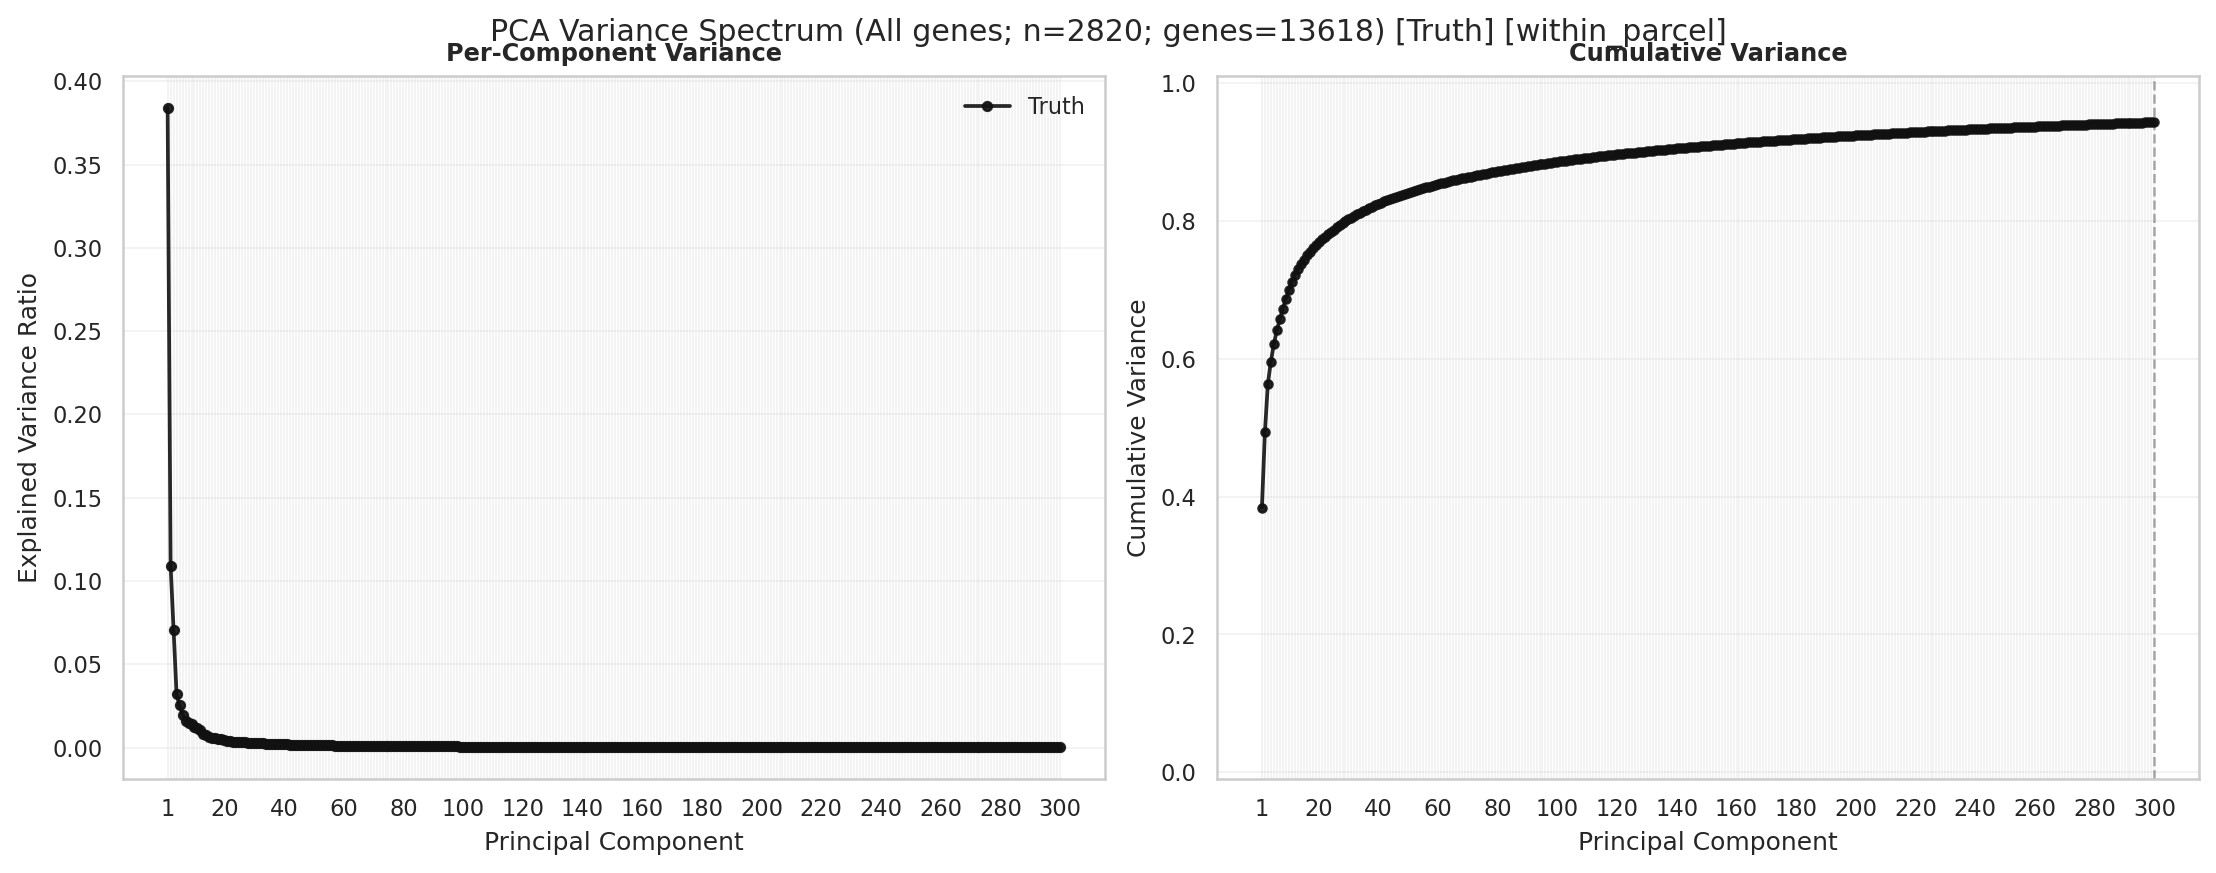

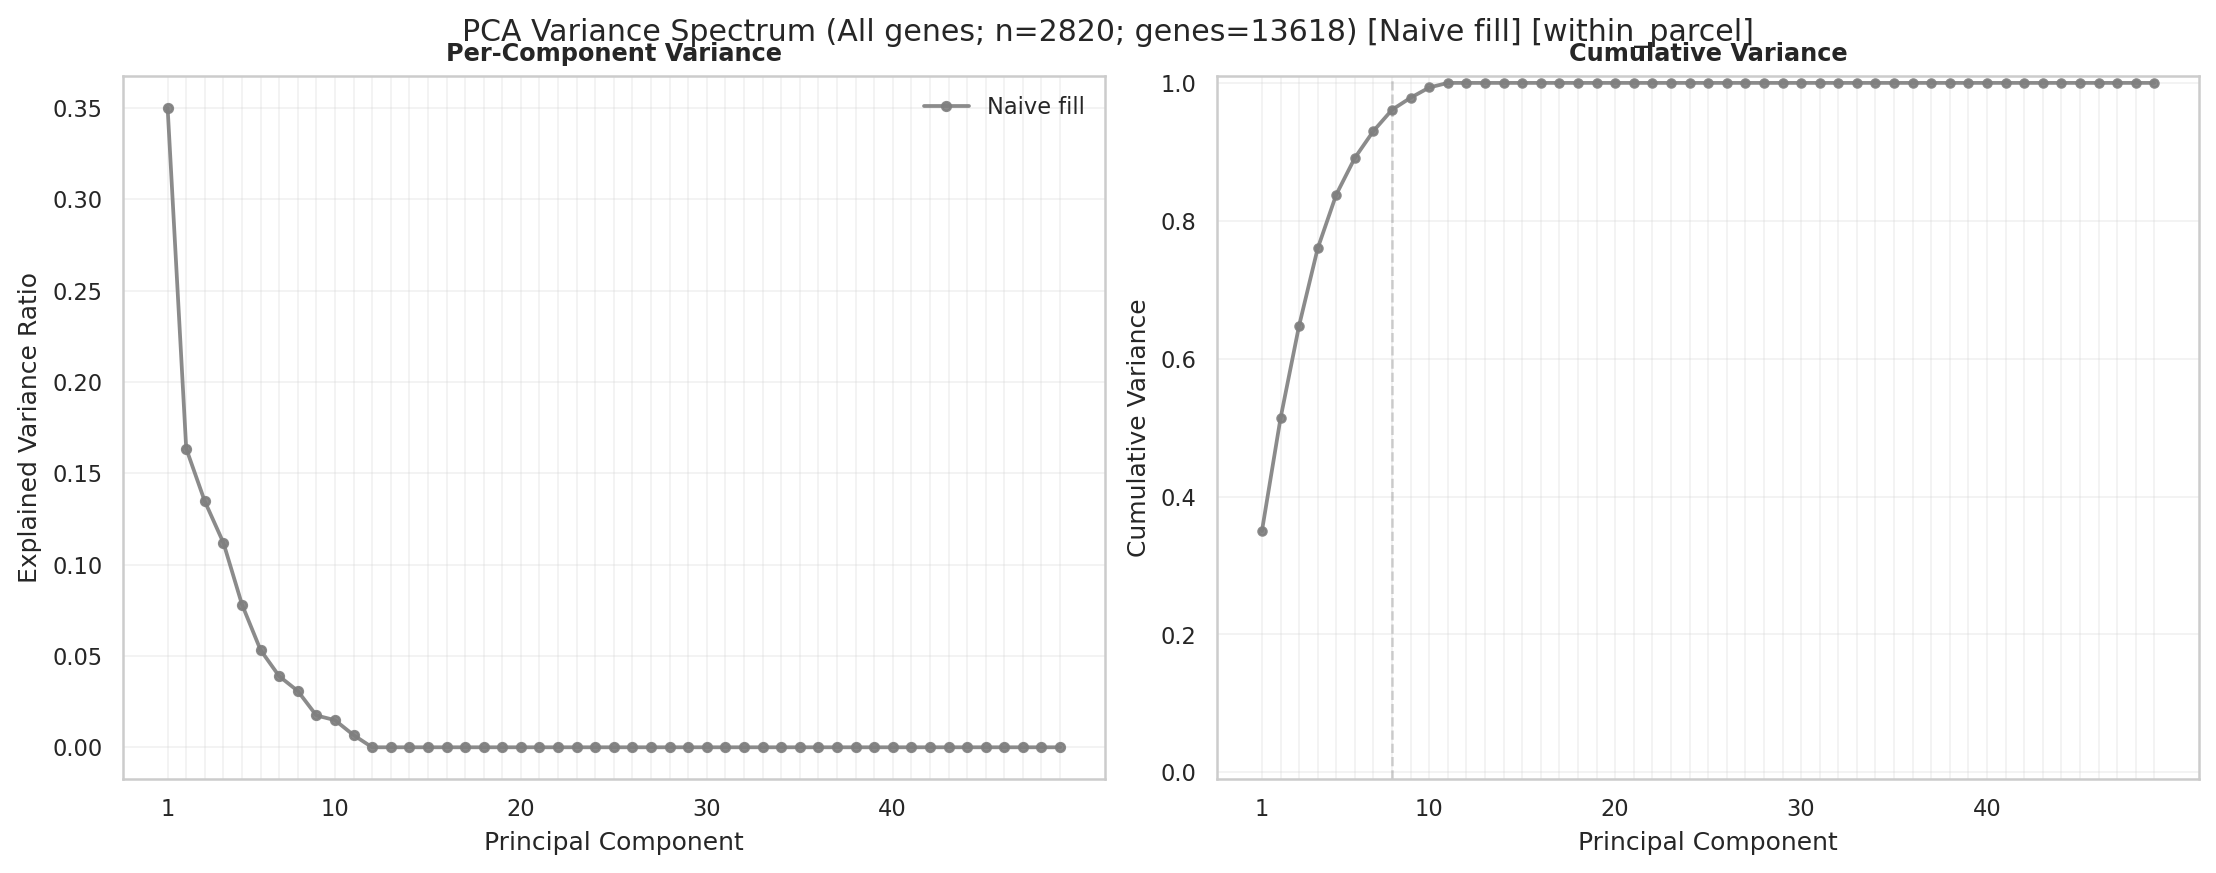

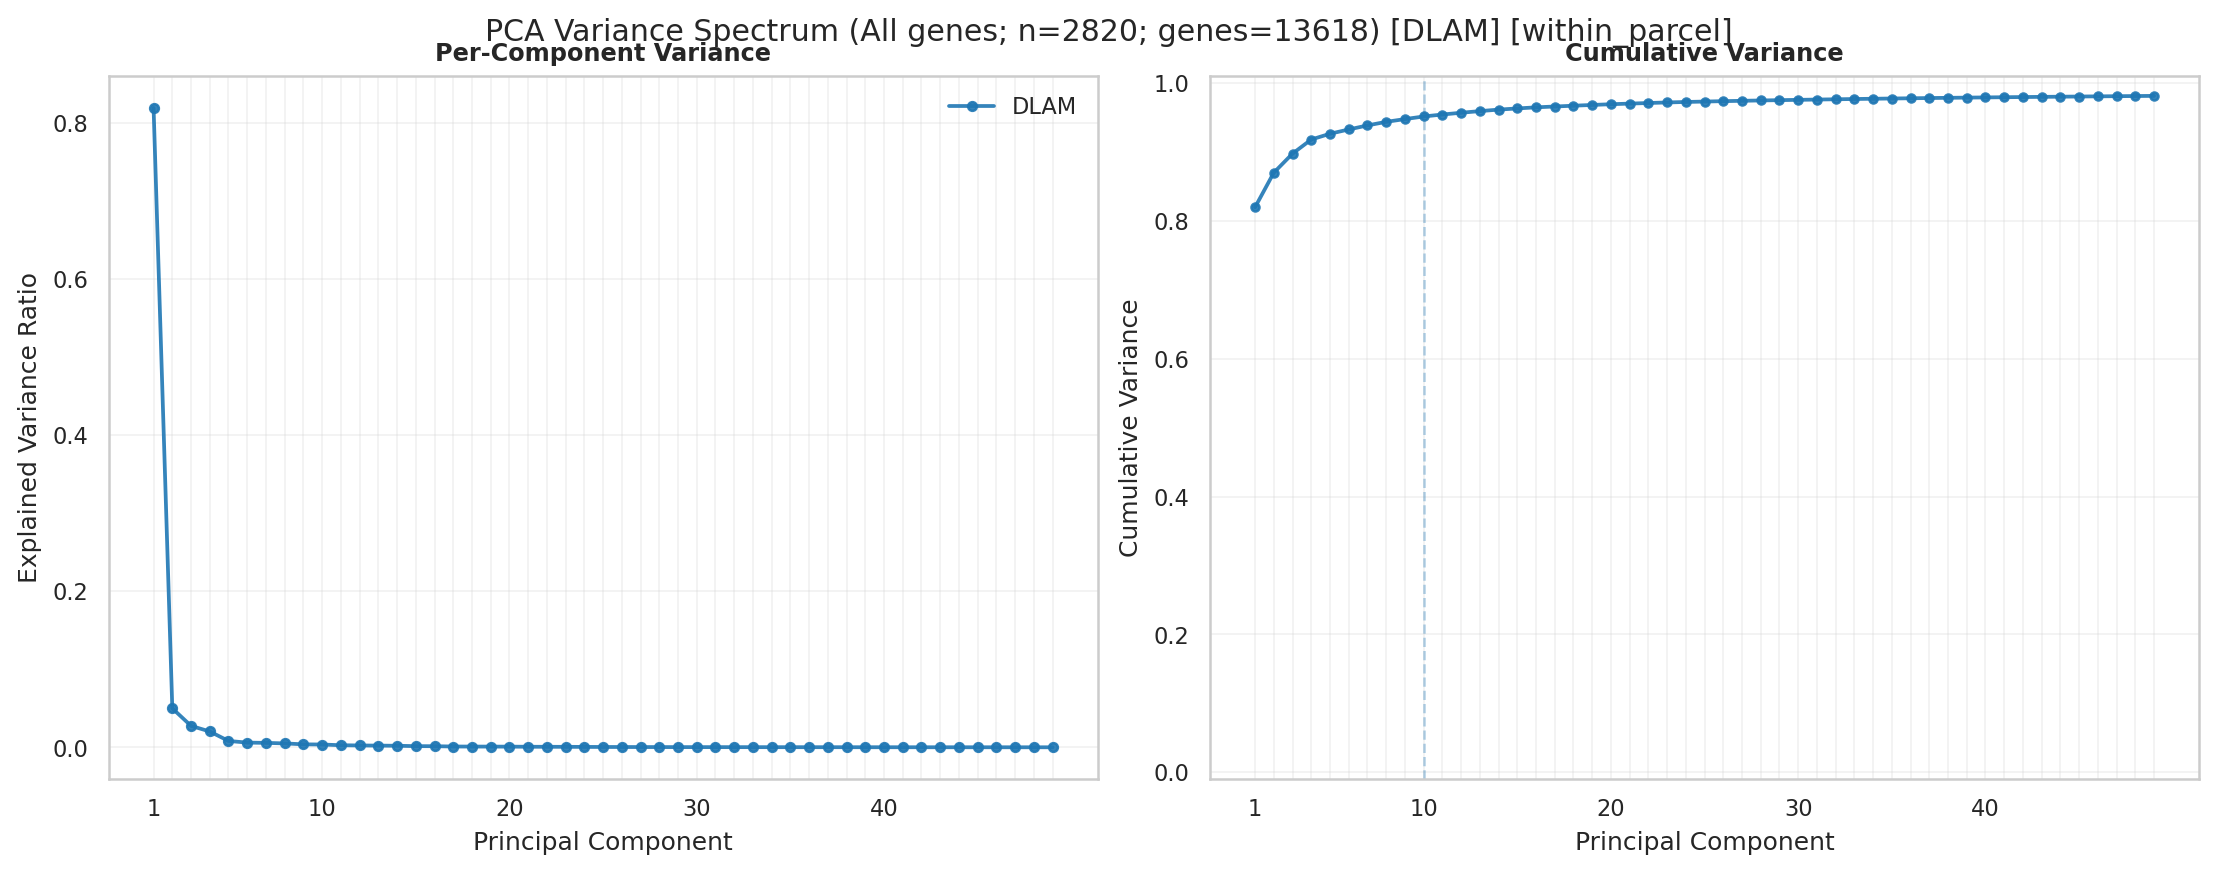

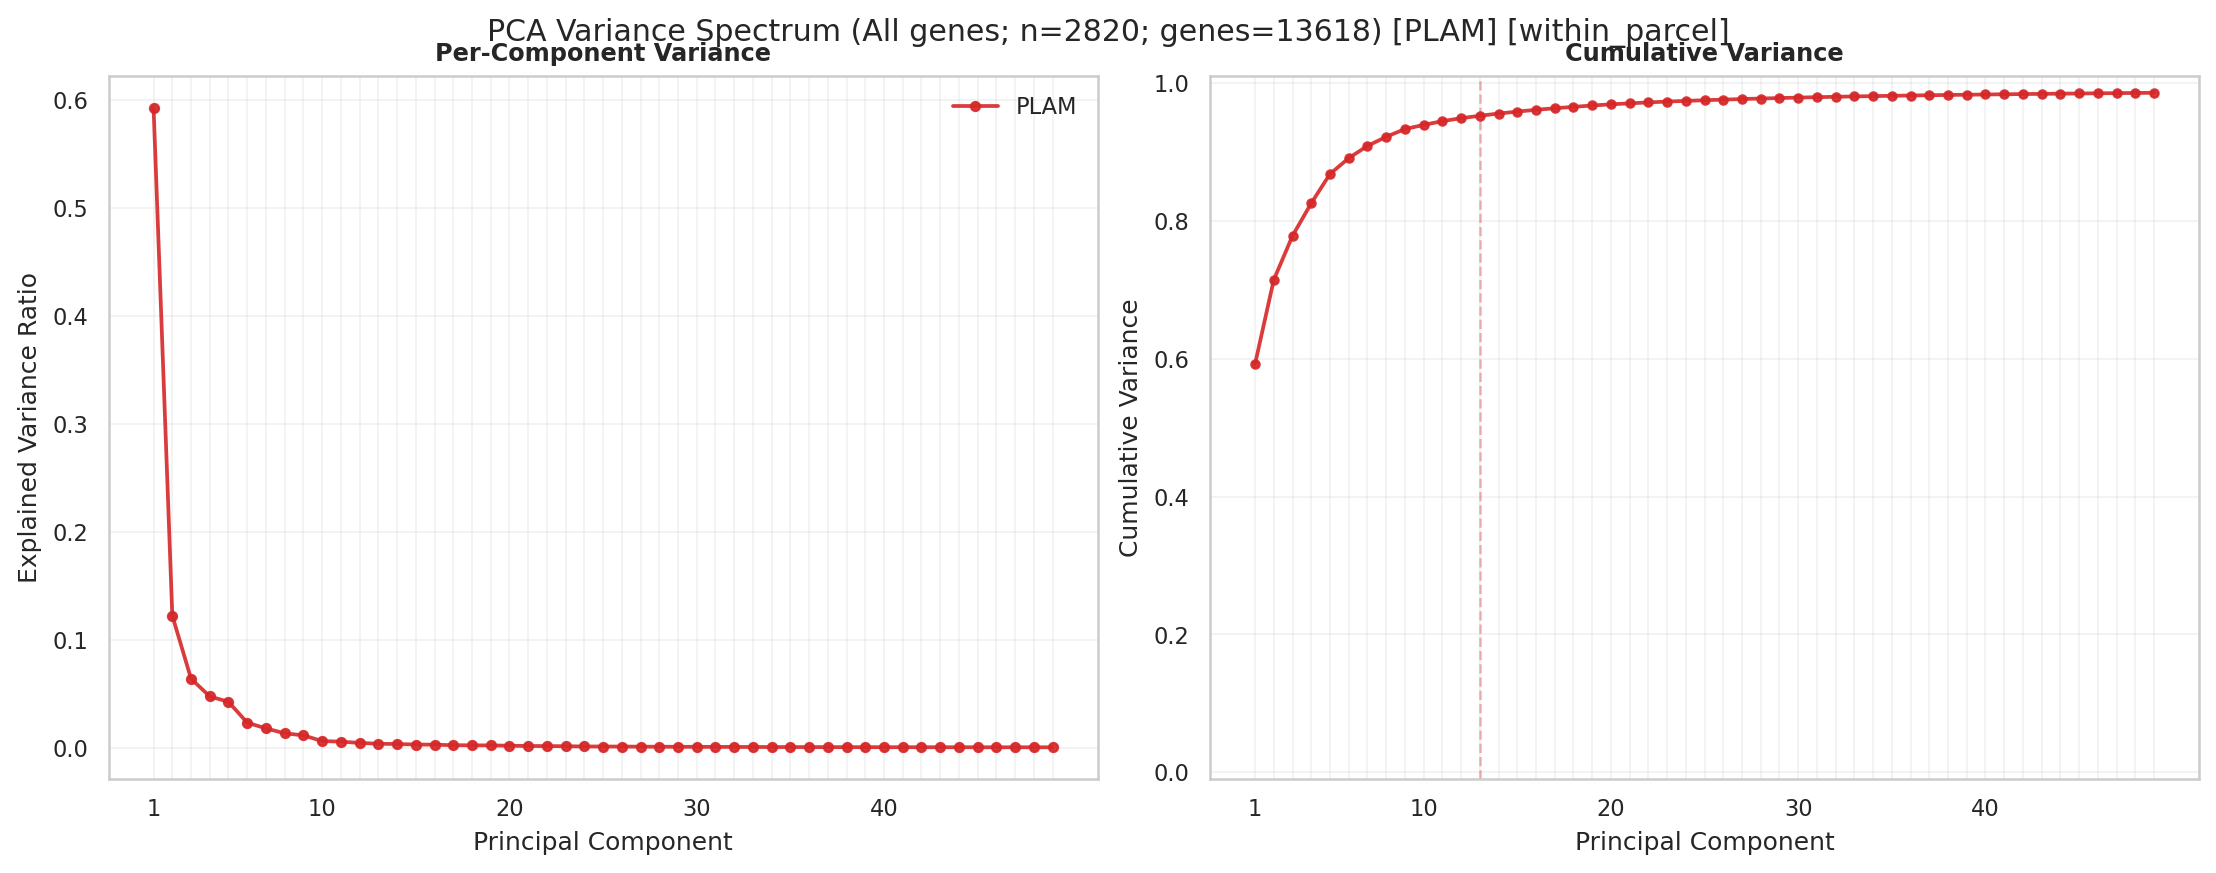

In [28]:
# Plot for 'truth' with 300 PCs and x_label_stride=10
fig, axes, _ = plot_pooled_pca_variance_spectra(
    spectra_df_dm[(spectra_df_dm['source'] == 'truth') & (spectra_df_dm['component'] < 350)],
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
    show_decay_fit=False,
    x_label_stride=20,
    source='truth',
)

# Plot for 'naive' with 300 PCs and x_label_stride=10
fig, axes, _ = plot_pooled_pca_variance_spectra(
    spectra_df_dm[(spectra_df_dm['source'] == 'naive') & (spectra_df_dm['component'] < 50)],
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
    show_decay_fit=False,
    x_label_stride=10,
    source='naive',
)

# Plot for 'dlam' with 300 PCs and x_label_stride=10
fig, axes, _ = plot_pooled_pca_variance_spectra(
    spectra_df_dm[(spectra_df_dm['source'] == 'dlam') & (spectra_df_dm['component'] < 50)],
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
    show_decay_fit=False,
    x_label_stride=10,
    source='dlam',
)

# Plot for 'plam' with 300 PCs and x_label_stride=10
fig, axes, _ = plot_pooled_pca_variance_spectra(
    spectra_df_dm[(spectra_df_dm['source'] == 'plam') & (spectra_df_dm['component'] < 50)],
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
    show_decay_fit=False,
    x_label_stride=10,
    source='plam',
)


### Within-Parcel PCA Recovery: Raw Line Plot

Now the recovery plot is testing alignment in the parcel-demeaned residual space, which is much closer to a subject-specific variance question than the standard pooled PCA.



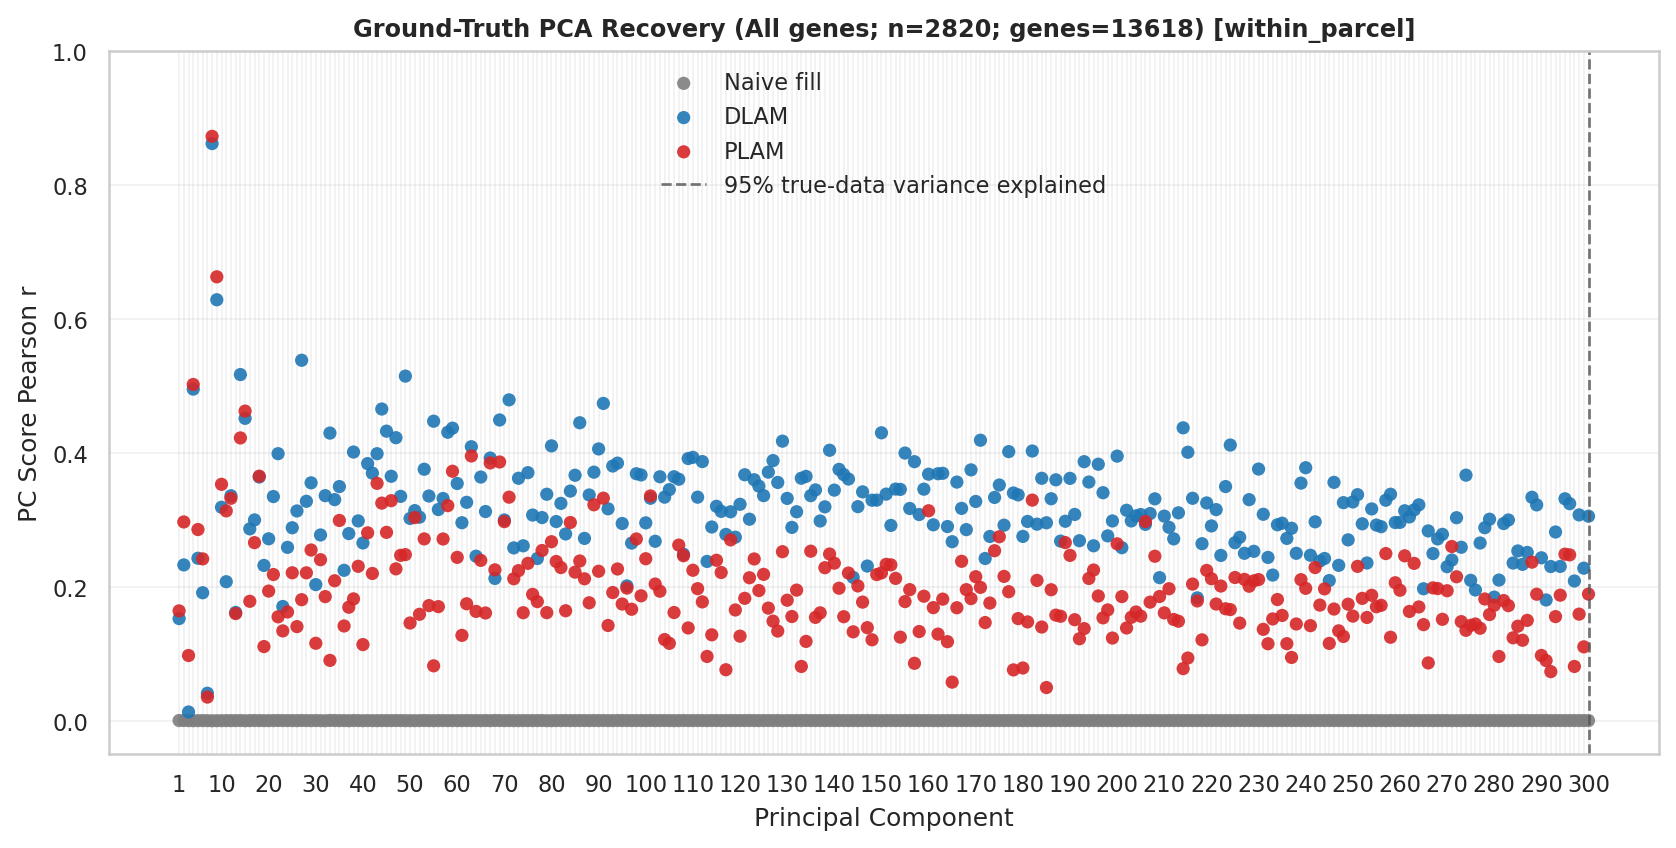

In [26]:
fig, ax, pc_plot_df_dm = plot_pooled_pca_recovery(
    pc_df_dm,
    metric='score_pearson',
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
    show_lines=False,
    show_decay_fit=False,
    x_label_stride=10,
)



### Within-Parcel PCA Recovery: Decay-Fit View

This view keeps the raw component-wise points but overlays a smooth fit for each model so the overall recovery profile is easier to compare.



/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/results_eda.py:2162: RuntimeWarning: overflow encountered in exp
  


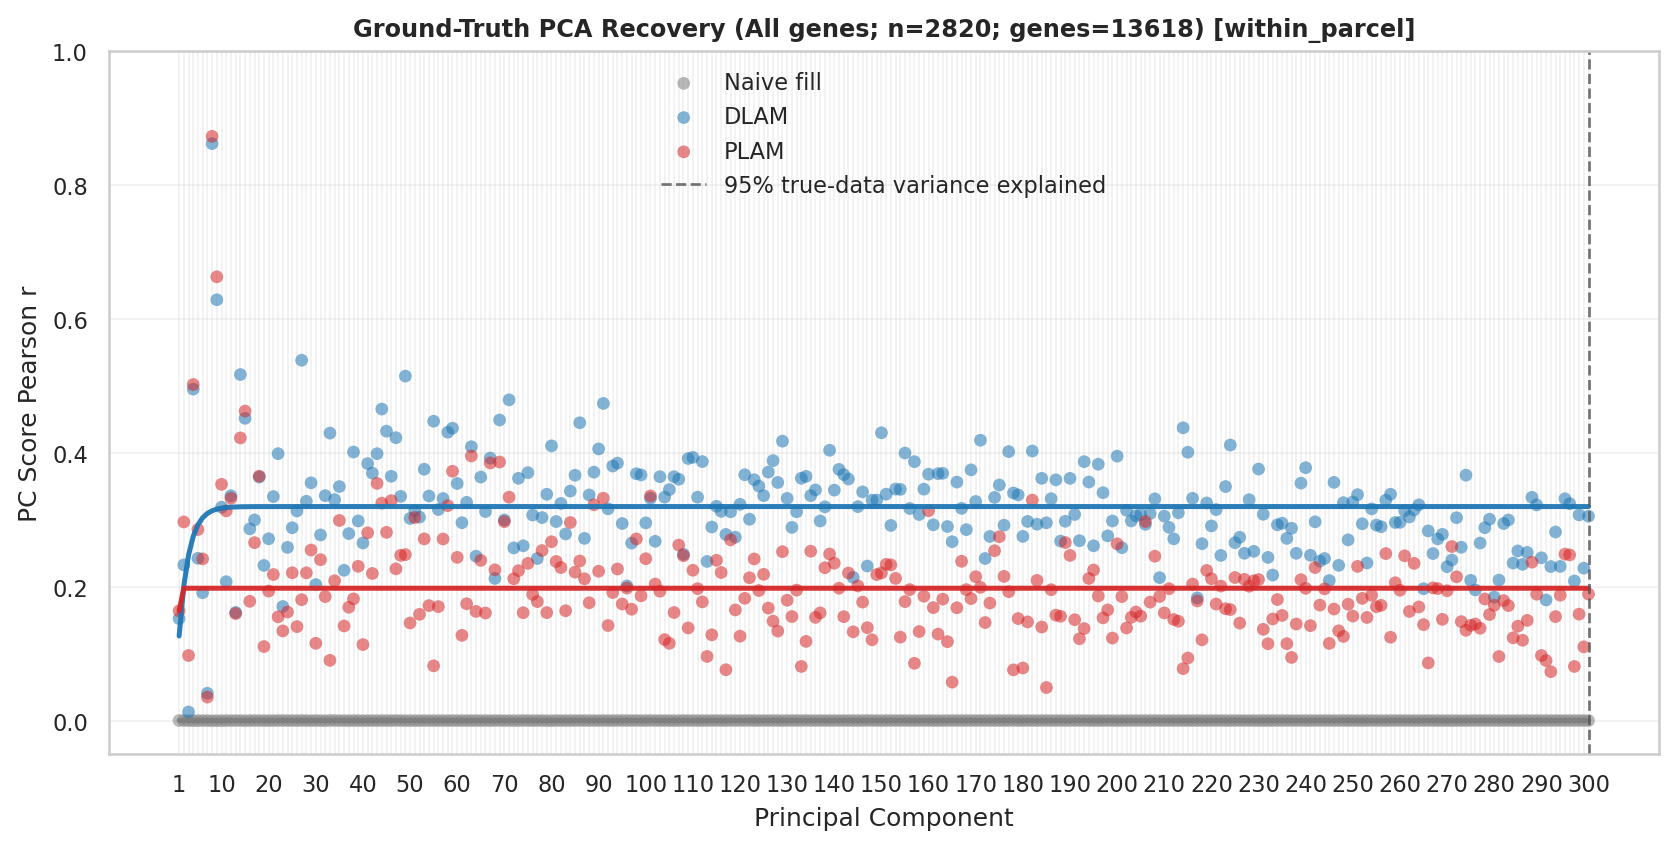

In [29]:
fig, ax, pc_plot_df_dm_fit = plot_pooled_pca_recovery(
    pc_df_dm,
    metric='score_pearson',
    panel_label='All genes' if EVAL_GENE_PATH is None else str(EVAL_GENE_PATH),
    show_decay_fit=True,
    x_label_stride=10,
)



## 5) Within-Parcel Variance Check

This is a useful companion diagnostic.

Why:
- PCA recovery asks whether predicted variation aligns with the true latent axes
- within-parcel variance asks whether the model produces subject-to-subject variation at all

A model can have substantial within-parcel variance but still fail to align that variance with the dominant true PCA directions.



In [ ]:
for name, df in {
    'truth': truth_df_naive,
    'naive': pred_df_naive,
    'dlam': pred_df_dlam,
    'plam': pred_df_plam,
}.items():
    vals = df.groupby('parcel_idx')[gene_cols].std().mean(axis=1) # variance mins and maxes
    print(f'\n{name}')
    display(vals.describe())



truth


count    12.000000
mean      0.301164
std       0.033857
min       0.234322
25%       0.279534
50%       0.313824
75%       0.325411
max       0.338583
dtype: float64


naive


count    12.000000
mean      0.000387
std       0.000130
min       0.000274
25%       0.000311
50%       0.000329
75%       0.000421
max       0.000719
dtype: float64


dlam


count    12.000000
mean      0.556239
std       0.022225
min       0.509112
25%       0.545288
50%       0.556929
75%       0.575652
max       0.582755
dtype: float64


plam


count    12.000000
mean      0.411463
std       0.017603
min       0.384582
25%       0.405071
50%       0.408138
75%       0.420814
max       0.445883
dtype: float64